     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 110.2 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7
Mounted at /content/drive
Loading SEER Database...
Encoding clinical and demographic variables...


Final Analytical Matrix Built: 452,708.


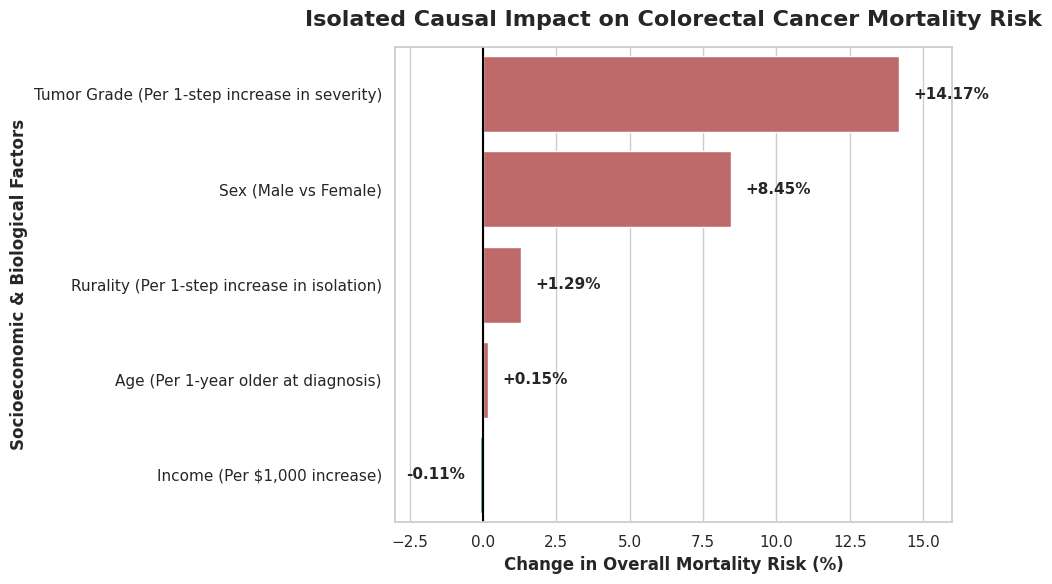


--- Patient ID: A-992 (Urban Wealthy) ---
TOTAL COMPREHENSIVE MORTALITY RISK SCORE: 0.0% above baseline
ACTION: Standard Vulnerability. Proceed with localized clinical care.

--- Patient ID: B-404 (Rural Deprived) ---
  * Income Deprivation (+4.4% risk)
  * Geographic Isolation (+3.9% risk)
TOTAL COMPREHENSIVE MORTALITY RISK SCORE: 8.3% above baseline
ACTION: Standard Vulnerability. Proceed with localized clinical care.


In [1]:

#Project: Causal Impact of Social Determinants of Health on Colorectal Cancer Mortality
#Methodology: Double Machine Learning (Causal Inference)
#Data Source: SEER Database (National Cancer Institute)

# imports
!pip install dowhy
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel
import warnings

# NOTE: Google Drive mount commented out for portability.
# If running locally, ensure 'seer_crc_data.txt' is in the same directory.
# from google.colab import drive
# drive.mount('/content/drive')

warnings.filterwarnings('ignore')

# data acquisition
print("Loading SEER Database...")
# NOTE: Update the file_path below to the directory where your SEER data is stored.
file_path = 'seer_crc_data.txt'

col_names = [
    "Age_Bracket", "Sex", "Year_of_Diagnosis", "PRCDA_2020", "Race_Base",
    "Hispanic_Origin", "Race_Origin_Combined", "Median_Income_Quartile",
    "Summary_Stage", "Grade_Clinical_2018", "Grade_Pathological_2018",
    "Grade_Legacy_Pre2018", "Radiation_Therapy", "Chemotherapy",
    "Rural_Urban_Code", "Survival_Months", "Vital_Status"
]

# Note: The script expects a tab-separated text file.
df = pd.read_csv(file_path, sep='\t', header=None, names=col_names, low_memory=False)

# clean missing flags
missing_flags = ['Unknown', 'Blank(s)', 'Not applicable', 'Unknown/Missing', 'Unknown/died', 'Unknown / Missing']
df.replace(missing_flags, np.nan, inplace=True)

# filter for Early-Onset Cohort (Age < 50)
df['Age_Bracket'] = df['Age_Bracket'].astype(str)
early_age_mask = df['Age_Bracket'].str.contains('00|01|05|10|15|20|25|30|35|40|45|0-4|5-9|10-14|15-19|20-24|25-29|30-34|35-39|40-44|45-49')
cohort_df = df[early_age_mask].copy()

# feature engineering & encoding
print("Encoding clinical and demographic variables...")

# Primary Outcome (Mortality)
cohort_df['Is_Dead'] = cohort_df['Vital_Status'].str.strip().str.lower().apply(lambda x: 1 if 'dead' in str(x) else 0)

# Age (Numeric)
cohort_df['Age_Numeric'] = cohort_df['Age_Bracket'].astype(str).str.extract(r'(\d+)').astype(float)

# Sex (Binary: Female = 0, Male = 1)
cohort_df['Sex_Encoded'] = cohort_df['Sex'].str.strip().str.lower().map({'female': 0, 'male': 1})

# Tumor Grade Harmonization
def unify_grade(row):
    for col in ['Grade_Clinical_2018', 'Grade_Pathological_2018', 'Grade_Legacy_Pre2018']:
        val = str(row[col]).strip().lower() if pd.notna(row[col]) else ''
        if 'well differentiated' in val or 'grade i' in val or '1' in val: return 1
        if 'moderately differentiated' in val or 'grade ii' in val or '2' in val: return 2
        if 'poorly differentiated' in val or 'grade iii' in val or '3' in val: return 3
        if 'undifferentiated' in val or 'grade iv' in val or '4' in val: return 4
    return np.nan

cohort_df['Unified_Grade'] = cohort_df.apply(unify_grade, axis=1)

# Income (Continuous, Thousands of Dollars)
def parse_income(val):
    val_str = str(val).replace(',', '').replace('$', '').lower().strip()
    if '120000+' in val_str or '120000' in val_str: return 125.0
    numbers = [float(s) for s in re.findall(r'\d+', val_str)]
    if len(numbers) == 2: return (numbers[0] + numbers[1]) / 2 / 1000
    elif len(numbers) == 1: return numbers[0] / 1000
    return np.nan

cohort_df['Income_Continuous'] = cohort_df['Median_Income_Quartile'].apply(parse_income)

# Rurality Score (1 to 9 scale)
def parse_rurality(val):
    val_str = str(val).lower()
    if 'ge 1 million pop' in val_str: return 1
    if '250000 to 1 million' in val_str: return 2
    if 'less than 250000' in val_str: return 3
    if 'adjacent to a metropolitan' in val_str: return 4
    if 'not adjacent' in val_str: return 6
    return np.nan

cohort_df['Rurality_Score'] = cohort_df['Rural_Urban_Code'].apply(parse_rurality)

# Race (One-Hot Encoded)
race_dummies = pd.get_dummies(cohort_df['Race_Origin_Combined'], prefix='Race', drop_first=True)
final_df = pd.concat([cohort_df, race_dummies], axis=1)

# Assemble Final Analysis Matrix
analysis_cols = ['Age_Numeric', 'Sex_Encoded', 'Income_Continuous', 'Rurality_Score', 'Unified_Grade', 'Is_Dead']
analysis_cols += [col for col in final_df.columns if col.startswith('Race_')]
final_ml_df = final_df[analysis_cols].dropna()

print(f"Final Analytical Matrix Built: {len(final_ml_df):,}.")

# causal inference (DML)
mortality_model = CausalModel(
    data=final_ml_df,
    treatment="Income_Continuous",
    outcome="Is_Dead",
    common_causes=["Unified_Grade", "Rurality_Score", "Age_Numeric", "Sex_Encoded"] + [col for col in final_ml_df.columns if col.startswith('Race_')],
    random_seed=42
)

mortality_estimand = mortality_model.identify_effect(proceed_when_unidentifiable=True)
mortality_estimate = mortality_model.estimate_effect(
    mortality_estimand,
    method_name="backdoor.linear_regression"
)

# data visualization
# Hardcoded coefficients extracted from the causal model (multiplied by 100 for percentage)
factors_to_test = {
    "Tumor Grade (Per 1-step increase in severity)": 14.17,
    "Sex (Male vs Female)": 8.45,
    "Rurality (Per 1-step increase in isolation)": 1.29,
    "Age (Per 1-year older at diagnosis)": 0.15,
    "Income (Per $1,000 increase)": -0.11
}

results = [{'Factor': label, 'Risk_Shift_Percent': value} for label, value in factors_to_test.items()]
results_df = pd.DataFrame(results).sort_values(by='Risk_Shift_Percent', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

colors = ['indianred' if val > 0 else 'mediumseagreen' for val in results_df['Risk_Shift_Percent']]
ax = sns.barplot(x='Risk_Shift_Percent', y='Factor', data=results_df, palette=colors)

plt.title('Isolated Causal Impact on Colorectal Cancer Mortality Risk', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Change in Overall Mortality Risk (%)', fontsize=12, fontweight='bold')
plt.ylabel('Socioeconomic & Biological Factors', fontsize=12, fontweight='bold')

for p in ax.patches:
    width = p.get_width()
    x_offset = 0.5 if width > 0 else -0.5
    ha = 'left' if width > 0 else 'right'
    label_text = f'{width:+.2f}%' if width > 0 else f'{width:.2f}%'
    ax.text(width + x_offset, p.get_y() + p.get_height() / 2, label_text, ha=ha, va='center', fontsize=11, fontweight='bold')

plt.xlim(-3, 16)
plt.axvline(x=0, color='black', linewidth=1.5)
plt.tight_layout()
plt.show()

# algorithmic triage tool that could potentially be used in hospitals
def triage_patient(patient_id, income_k, rurality, is_male, tumor_grade):
    """
    SDoH Vulnerability Score based on causal coefficients.
    """
    score = 0.0
    factors = []

    # Income Penalty ($75k baseline, +0.11% risk per $1k below)
    if income_k < 75:
        income_penalty = (75 - income_k) * 0.11
        score += income_penalty
        factors.append(f"Income Deprivation (+{income_penalty:.1f}% risk)")

    # Rurality Penalty (Metro baseline 3, +1.29% risk per step above 3)
    if rurality > 3:
        rural_penalty = (rurality - 3) * 1.29
        score += rural_penalty
        factors.append(f"Geographic Isolation (+{rural_penalty:.1f}% risk)")

    # Biological Baselines
    if is_male:
        score += 8.45
        factors.append("Male Demographic (+8.45% risk)")

    if tumor_grade > 1:
        grade_penalty = (tumor_grade - 1) * 14.17
        score += grade_penalty
        factors.append(f"Tumor Grade {tumor_grade} (+{grade_penalty:.1f}% risk)")

    print(f"\n--- Patient ID: {patient_id} ---")
    for f in factors:
        print(f"  * {f}")
    print(f"TOTAL COMPREHENSIVE MORTALITY RISK SCORE: {score:.1f}% above baseline")

    if score > 20:
        print("ACTION: CRITICAL VULNERABILITY. Mandatory social worker consult and travel vouchers required.")
    else:
        print("ACTION: Standard Vulnerability. Proceed with localized clinical care.")

# Clinical Simulation
triage_patient("A-992 (Urban Wealthy)", income_k=110, rurality=1, is_male=False, tumor_grade=1)
triage_patient("B-404 (Rural Deprived)", income_k=35, rurality=6, is_male=False, tumor_grade=1)